# Регрессия для SI

Необходимо сравнить различные модели с настройкой гиперпараметров для предсказания значения индекса селективности соединений (SI) на основе их молекулярных дескрипторов.

SI является количественной целевой переменной, характеризующей избирательность действия потенциальных лекарственных соединений, и вычисляется как отношение CC50 к IC50 (SI = CC50 / IC50). Чем выше значение SI, тем более селективно соединение - оно эффективно подавляет патоген (низкий IC50) и при этом малотоксично для организма (высокий CC50).

При моделировании SI важно помнить, что IC50 и CC50 не могут использоваться в качестве признаков, так как SI напрямую зависит от этих величин, что привело бы к утечке данных.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

import xgboost as xgb
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

## Загрузка данных

In [ ]:
df = pd.read_csv('clean_data.csv')
print('Размерность датасета:', df.shape)

Размерность датасета: (969, 213)


In [ ]:
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.describe()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,...,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.0,969.000000,969.000000,969.000000
mean,220.726223,586.419908,73.967907,10.893712,10.893712,0.179533,-0.960140,0.577633,29.370350,351.486139,...,0.055728,0.012384,0.009288,0.001032,0.001032,0.053664,0.0,0.070175,0.208462,0.007224
std,397.172441,633.624464,695.564665,3.284005,3.284005,0.168928,1.567568,0.213316,12.605779,127.388186,...,0.263069,0.110649,0.095975,0.032125,0.032125,0.225469,0.0,0.255574,1.231428,0.084730
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999345,1.488095,10.006389,10.006389,0.050979,-1.333174,0.442842,18.500000,266.252000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,45.338355,424.166213,3.900000,12.196496,12.196496,0.123850,-0.419485,0.634372,29.200000,318.373000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,231.373089,891.776925,16.375000,13.178870,13.178870,0.291020,0.007873,0.742483,38.600000,413.670000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


## Подготовка данных к обучению модели

При моделировании необходимо учитывать, что индекс селективности SI вычисляется на основе значений IC50 и CC50. Следовательно, для задач прогнозирования SI нельзя использовать IC50 и CC50 в качестве признаков. Аналогично, при моделировании IC50 запрещено использовать SI и CC50, а при моделировании CC50 — SI и IC50, чтобы избежать утечки данных и некорректного завышения качества моделей.

Для решения задач регрессии с целевыми переменными, характеризующимися сильной асимметрией распределения, выявленной при анализе данных, применяется логарифмическое преобразование log1p. Расчет метрик качества при этом выполняется в логарифмической шкале, что позволяет корректно оценивать относительные ошибки предсказаний.

Построим графики распределния целевой переменной SI и ее логарифма log1p(SI).

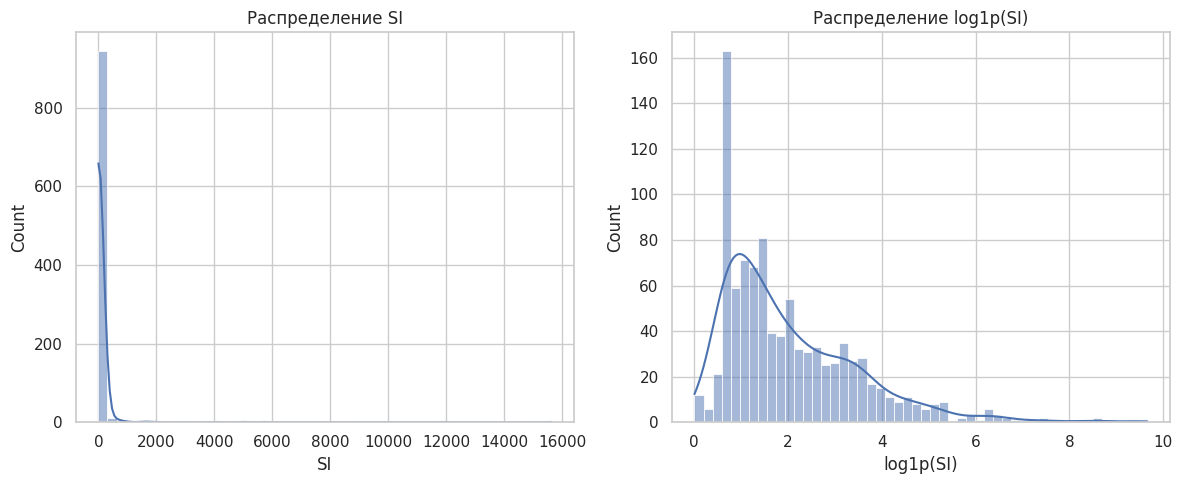

In [ ]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Исходное распределение SI
sns.histplot(df['SI'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Распределение SI')
axes[0].set_xlabel('SI')

# Логарифмическое распределение SI
sns.histplot(np.log1p(df['SI']), kde=True, bins=50, ax=axes[1])
axes[1].set_title('Распределение log1p(SI)')
axes[1].set_xlabel('log1p(SI)')

plt.tight_layout()
plt.show()

In [ ]:
# Удаляем утечки, так как SI = CC50/IC50
df = df.drop(columns=['IC50, mM', 'CC50, mM'])

# Признаки / таргет
X = df.drop(columns=['SI'])
y =  np.log1p(df['SI'])

Так как ранее на этапе EDA в общей даграмме присутствовало много признаков, которые сильно коррелируют между собой, напишем функцию для устранения мультиколлинеарности путем удаления этих сильно коррелирующих между собой переменных.

In [ ]:
def drop_high_corr(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

X, dropped_cols = drop_high_corr(X, threshold=0.8)

print(f"Удалено {len(dropped_cols)} признаков")

Удалено 72 признаков


Данная функция вычисляет матрицу абсолютных коэффициентов корреляции Пирсона для всех признаков, выделяет верхнюю треугольную часть матрицы, исключая главную диагональ и идентифицирует пары признаков, коэффициент корреляции между которыми превышает заданный порог. Для каждой такой пары функция помечает один из признаков для удаления, оставляя в датасете только некоррелирующие между собой переменные.

Это важно для многих моделей машинного обучения, особенно линейных, где высокая корреляция между признаками приводит к нестабильности оценок коэффициентов, снижению интерпретируемости и переобучению.

Дополнительно проведем количественную оценку мультиколлинеарности в наборе признаков с использованием фактора инфляции дисперсии.

In [ ]:
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False)

vif_result = calculate_vif(X)
vif_result

high_vif_features = vif_result[vif_result['VIF'] > 40]['features'].tolist()
X_clean = X.drop(columns=high_vif_features)
X_clean

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.094096,0.387225,0.387225,0.417362,42.928571,0,0.038844,-0.293526,0.642857,14.822266,...,0,0,0,0,0,0,0,0,3,0
1,3.961417,0.533868,0.533868,0.462473,45.214286,0,0.012887,-0.313407,0.607143,14.975110,...,0,0,0,0,0,0,0,0,3,0
2,2.627117,0.543231,0.543231,0.260923,42.187500,0,0.094802,-0.325573,0.562500,15.353938,...,0,0,0,0,0,0,0,0,3,0
3,5.097360,0.390603,0.390603,0.377846,41.862069,0,0.038844,-0.293526,0.620690,14.821216,...,0,0,0,0,0,0,0,0,4,0
4,5.150510,0.270476,0.270476,0.429038,36.514286,0,0.062897,-0.257239,0.600000,14.831112,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964,12.934891,0.048029,-0.476142,0.382752,49.133333,0,0.317890,-0.468587,1.133333,16.586886,...,0,0,0,0,0,0,0,0,0,0
965,13.635345,0.030329,-0.699355,0.369425,44.542857,0,0.327562,-0.467493,1.085714,16.586914,...,0,0,0,0,0,0,0,0,0,0
966,13.991690,0.026535,-0.650790,0.284923,41.973684,0,0.327887,-0.467485,1.157895,32.166365,...,1,0,0,0,0,0,0,0,0,0
967,13.830180,0.146522,-1.408652,0.381559,39.000000,0,0.312509,-0.468755,0.756757,16.540061,...,0,0,0,0,0,0,0,0,0,0


Эта функция вычисляет каждого признака VIF, который показывает, насколько сильно дисперсия оцененного коэффициента регрессии увеличивается из-за корреляции этого признака с другими признаками. Значение VIF вычисляется как отношение дисперсии модели со всеми признаками к дисперсии модели, где данный признак регрессируется на все остальные.

Чем выше значение VIF, тем сильнее мультиколлинеарность: для нашей задачи будем использовать пороговое значение 40.

Таким образом, с использованием двух методов мы избавимся от мультиколлинеарности.



Разделим данные на тренировочную и тестовую выборки:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 775 строк
Тестовая выборка: 194 строк


## Обучение моделей

Для данной задачи будем рассматривать 6 различных моделей: гребневая регрессия, регрессия Лассо, случайный лес, градиентный бустинг, XGBoost и LightGBM.

Для каждой модели проводится подбор гиперпараметров с помощью GridSearchCV и 5-кратной кросс-валидации, в качестве метрики оптимизации выбрана среднеквадратичная ошибка (MSE).

Оценивать качество моделей будем по трем метрикам:
- средняя абсолютная ошибка - MAE
- корень из среднеквадратичной ошибки - RMSE
- коэффициент детерминации - R^2

In [ ]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "MAE_train": mean_absolute_error(y_train, pred_train),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "R2_test": r2_score(y_test, pred_test)
    }

Выше представлена общая функция для предсказания и оценки модели. Она обучает модель на тренировочных данных, делает предсказания на обеих выборках и возвращает ключевые метрики: MAE (на обучении и тесте), RMSE и R^2 на тестовых данных.

Перейдем к обучению моделей:

**Гребневая регрессия**

In [ ]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])

params_ridge = {
    'model__alpha': [0.1, 1, 10, 50, 100, 150, 200]
}

grid_ridge = GridSearchCV(ridge, params_ridge, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)

res_ridge = evaluate(grid_ridge.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_ridge.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_ridge.best_score_:.4f}")

Лучшие параметры: {'model__alpha': 150}
Наилучшая метрика MSE: 1.7490


**Регрессия Лассо**

In [ ]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42, max_iter=10000))
])

params_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 15]
}

grid_lasso = GridSearchCV(lasso, params_lasso, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

res_lasso = evaluate(grid_lasso.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_lasso.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_lasso.best_score_:.4f}")

Лучшие параметры: {'model__alpha': 0.01}
Наилучшая метрика MSE: 1.7915


**Случайный лес**

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

params_rf = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [4, 6, 8],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 0.5, 0.7],
    'bootstrap': [True, False],
}

grid_rf = GridSearchCV(rf, params_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

res_rf = evaluate(grid_rf.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_rf.best_score_:.4f}")

Лучшие параметры: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 600}
Наилучшая метрика MSE: 1.4217


**Градиентный бустинг**

In [ ]:
gb = GradientBoostingRegressor(random_state=42)

params_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.02, 0.05, 0.1],
    'min_samples_split': [4, 6, 8],
    'min_samples_leaf': [2, 4],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.85, 1.0],
}

grid_gb = GridSearchCV(gb, params_gb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)

res_gb = evaluate(grid_gb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_gb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 100, 'subsample': 0.7}
Наилучшая метрика MSE: 1.4469


**XGBRegressor**

In [ ]:
xgbr = xgb.XGBRegressor(random_state=42, n_jobs=-1)

params_xgb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.02, 0.05, 0.1]
}

grid_xgb = GridSearchCV(xgbr, params_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

res_xgb = evaluate(grid_xgb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_xgb.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_xgb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 300}
Наилучшая метрика MSE: 1.5459


**LightGBM**

In [ ]:
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

params_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 100],
}

grid_lgbm = GridSearchCV(lgbm, params_lgbm, cv=5, scoring='neg_mean_squared_error',
                           n_jobs=-1, verbose=1)
grid_lgbm.fit(X_train, y_train)

res_lgbm = evaluate(grid_lgbm.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_lgbm.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_lgbm.best_score_:.4f}")

Соберем датафрейм с результатами моделей:

In [ ]:
results = pd.DataFrame({
    'Ridge': res_ridge,
    'Lasso': res_lasso,
    'RandomForest': res_rf,
    'GradientBoosting': res_gb,
    'XGBoost': res_xgb,
    'LGBMRegressor': res_lgbm
}).T

results.sort_values('RMSE_test')

,MAE_train,MAE_test,RMSE_test,R2_test
XGBoost,0.747363,0.977463,1.307245,0.243659
RandomForest,0.559398,0.947351,1.310348,0.240064
GradientBoosting,0.648093,0.970360,1.328275,0.219129
LGBMRegressor,0.486979,0.958781,1.345934,0.198228
Ridge,0.929176,1.032740,1.351497,0.191586
Lasso,0.918949,1.046976,1.361603,0.179451


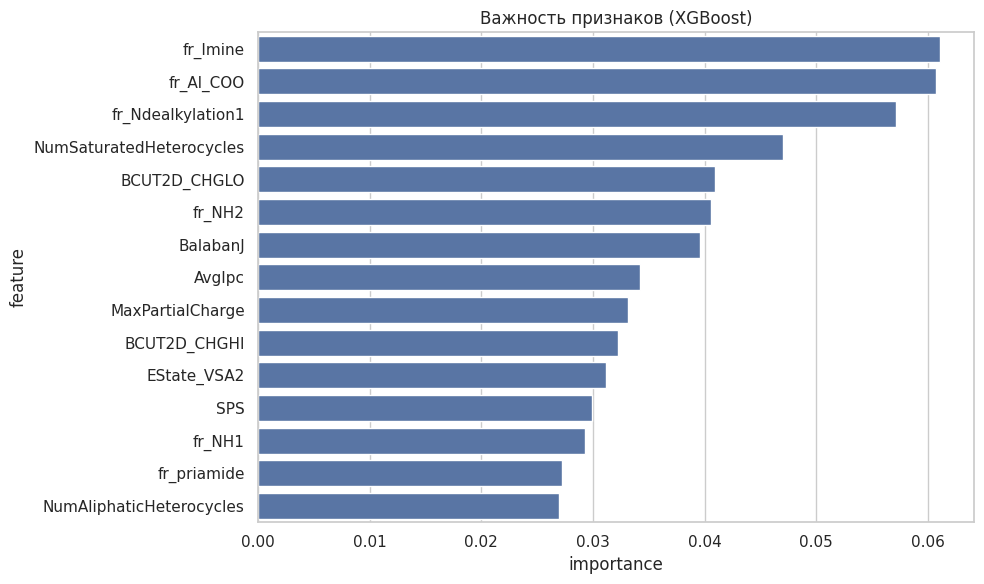

Топ-10 наиболее важных признаков:
                     feature  importance
42                  fr_Imine    0.061063
35                 fr_Al_COO    0.060681
46         fr_Ndealkylation1    0.057175
34  NumSaturatedHeterocycles    0.047009
12              BCUT2D_CHGLO    0.040912
44                    fr_NH2    0.040558
15                  BalabanJ    0.039613
14                    AvgIpc    0.034187
6           MaxPartialCharge    0.033138
11              BCUT2D_CHGHI    0.032266


In [ ]:
# Извлечем важность признаков из лучшей модели (XGBoost)
sns.set(style="whitegrid")
best_model = grid_xgb.best_estimator_
feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Важность признаков (XGBoost)')
plt.tight_layout()
plt.show()

print("Топ-10 наиболее важных признаков:")
print(feature_importance.head(10))

В результате построения 6 моделей можно сделать следующие выводы:

- Среди шести рассмотренных моделей лучшую обобщающую способность показал XGBoost, достигнув наибольшего R^2 = 0.244 и минимального RMSE на тестовой выборке. RandomForest продемонстрировал близкие результаты и минимальную абсолютную ошибку MAE = 0.947 Однако у обеих древовидных моделей наблюдается заметное переобучение, так как разрыв MAE между train и test составляет примерно 0.35-0.4. Линейные модели показали худшие результаты, что подтверждает нелинейный характер зависимости целевой переменной SI от молекулярных дескрипторов.

- Анализ важности признаков показал, что наибольший вклад в предсказание вносят фрагментные счетчики - fr_Imine, fr_Al_COO, fr_Ndealkylation1, и топологические индексы - BalabanJ, AvgIpc, что подчеркивает значимость химической структуры. При этом общий R^2 довольно низкий, то есть модель объясняет лишь около 24% дисперсии целевой переменной - этого недостаточно для надежного промышленного применения.

**Рекомендации:**

Для улучшения качества рекомендуется стоит рассомтреть применение ранней остановки в XGBoost и LightGBM для борьбы с переобучением, а также провести отбор топ-20 признаков для повышения стабильности линейных моделей. В перспективе стоит рассмотреть использование стекинга нескольких моделей, например XGBoost и RandomForest или перейти к использованию ансамблей, способным лучше учитывать топологию молекул. В текущем виде лучшей моделью для предсказания SI является XGBoost с последующей калибровкой гиперпараметров под конкретную задачу.

